# IMDB Top 1000 Movies — Data Analysis

The main goal of this project is to analyze the `top 1,000 movies dataset from IMDB`. Through this analysis, I aim to uncover underlying patterns, factors influencing movie ratings, and relationships between variables such as genre, gross revenue, and directors.

**Contents**
1. Data Loading & Initial Inspection
2. Data Cleaning
3. Outlier Detection (IQR)
4. Duration Analysis
5. Descriptive Statistics
6. Handling Invalid Gross Values
7. Release Year Trends
8. Genre Analysis
9. Rate vs. Metascore
10. Duration vs. Rate
11. Correlation Heatmap
12. Director Analysis
13. Top-Rated vs. Most-Voted Movies
14. Conclusion

## 1. Data Loading & Initial Inspection

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("IMDB_TOP_1000_Dataset.csv")

In [11]:
print(df.shape)
df.info()
df.head()

(1000, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1000 non-null   int64  
 1   Title        1000 non-null   str    
 2   Certificate  973 non-null    str    
 3   Duration     1000 non-null   str    
 4   Genre        1000 non-null   str    
 5   Rate         1000 non-null   float64
 6   Metascore    712 non-null    float64
 7   Description  1000 non-null   str    
 8   Cast         1000 non-null   str    
 9   Info         1000 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 78.3 KB


,Unnamed: 0,Title,Certificate,Duration,Genre,Rate,Metascore,Description,Cast,Info
0,0,1. The Shawshank Redemption (1994),R,142 min,Drama,9.3,80.0,Two imprisoned men bond over a number of years...,"Director: Frank Darabont | Stars: Tim Robbins,...","Votes: 2,295,987 | Gross: $28.34M"
1,1,2. The Godfather (1972),R,175 min,"Crime, Drama",9.2,100.0,The aging patriarch of an organized crime dyna...,Director: Francis Ford Coppola | Stars: Marlon...,"Votes: 1,584,782 | Gross: $134.97M"
2,2,3. The Dark Knight (2008),PG-13,152 min,"Action, Crime, Drama",9.0,84.0,When the menace known as the Joker wreaks havo...,Director: Christopher Nolan | Stars: Christian...,"Votes: 2,260,649 | Gross: $534.86M"
3,3,4. The Godfather: Part II (1974),R,202 min,"Crime, Drama",9.0,90.0,The early life and career of Vito Corleone in ...,Director: Francis Ford Coppola | Stars: Al Pac...,"Votes: 1,107,253 | Gross: $57.30M"
4,4,5. The Lord of the Rings: The Return of the Ki...,PG-13,201 min,"Action, Adventure, Drama",8.9,94.0,Gandalf and Aragorn lead the World of Men agai...,"Director: Peter Jackson | Stars: Elijah Wood, ...","Votes: 1,614,369 | Gross: $377.85M"


### 1.1 First Look

The dataset contains 1,000 movies and 10 columns. Key observations:

- The `Unnamed: 0` column is a redundant index and will be dropped.
- `Certificate` has 27 missing values.
- `Duration` is stored as a string (e.g., "142 min") and needs to be converted to a numeric type.
- `Genre` contains multiple genres per row (comma-separated) and needs further processing.
- The `Metascore` column contains 288 missing values (about 29% of the dataset). Removing these rows would eliminate nearly one-third of the observations and could reduce the reliability of the analysis. Since the missing values cannot be estimated confidently, they are kept as NaN.
- The `Cast` and `Info` columns likely contain multiple pieces of combined information and need to be inspected and split.

## 2. Data Cleaning

### 2.1 Removing Duplicate Entries

In [12]:
df = df.drop_duplicates(subset=['Title', 'Rate'])
df = df.reset_index(drop=True)
print(df.shape)

(398, 10)


### 2.2 Cleaning the `Title` Column

In [13]:
df['Year'] = df['Title'].str.extract(r'\((\d{4})\)').astype(int)
df['Title'] = df['Title'].str.replace(r'^\d+\.\s*', '', regex=True)
df['Title'] = df['Title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

In [14]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df['Certificate'] = df['Certificate'].fillna('Not Rated')

df['Duration'] = df['Duration'].str.replace(' min','')
df['Duration'] = df['Duration'].astype(np.int16)


df['Genre'] = df['Genre'].str.split(r',\s*')

In [15]:
df['Director'] = df['Cast'].str.split('|').str[0].str.replace('Director:', '').str.strip()

df['Stars'] = df['Cast'].str.split('|').str[1].str.replace('Stars:', '').str.strip()
df['Stars'] = df['Stars'].str.split(r',\s*')

df['Votes'] = df['Info'].str.split('|').str[0].str.replace('Votes:', '').str.strip()
df['Votes'] = df['Votes'].str.replace(',', '').astype(int)

df['Gross(M)'] = df['Info'].str.split('|').str[1].str.replace('Gross:', '').str.replace('$', '').str.replace('M', '').str.strip()
df['Gross(M)'] = df['Gross(M)'].astype(float)

df = df.drop(columns=['Cast', 'Info'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Title        398 non-null    str    
 1   Certificate  398 non-null    str    
 2   Duration     398 non-null    int16  
 3   Genre        398 non-null    object 
 4   Rate         398 non-null    float64
 5   Metascore    286 non-null    float64
 6   Description  398 non-null    str    
 7   Year         398 non-null    int64  
 8   Director     398 non-null    object 
 9   Stars        398 non-null    object 
 10  Votes        398 non-null    int64  
 11  Gross(M)     332 non-null    float64
dtypes: float64(3), int16(1), int64(2), object(3), str(3)
memory usage: 35.1+ KB


## 3. Outlier Detection Using IQR

In [16]:
numeric_columns = ["Duration", "Votes", "Gross(M)"]

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Duration: 9 outliers
Votes: 10 outliers
Gross(M): 29 outliers


## 4. Duration Analysis

### 4.1 Rating Distribution

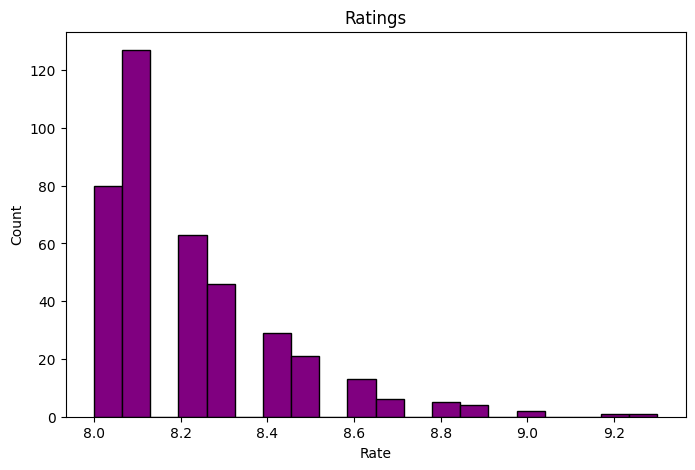

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['Rate'], bins=20, edgecolor='black', color='purple')
plt.title('Ratings')
plt.xlabel('Rate')
plt.ylabel('Count')
plt.show()

### 4.2 Duration Distribution

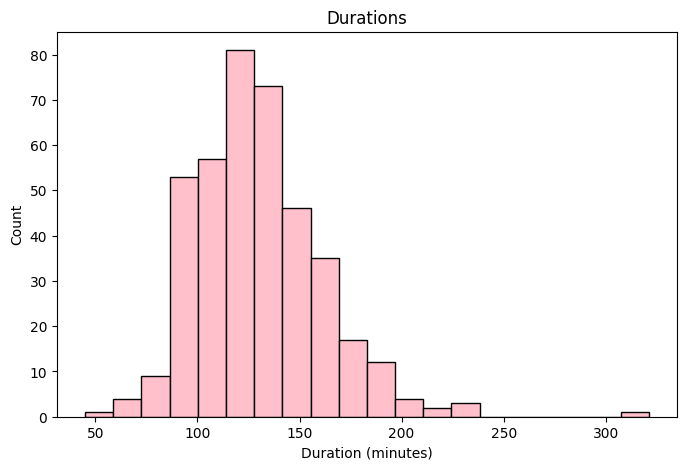

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df['Duration'], bins=20, edgecolor='black', color='pink')
plt.title('Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

## 5. Descriptive Statistics

In [19]:
df[['Rate', 'Metascore', 'Duration', 'Votes', 'Gross(M)']].describe()

,Rate,Metascore,Duration,Votes,Gross(M)
count,398.000000,286.000000,398.000000,3.980000e+02,332.000000
mean,8.214322,82.241259,129.751256,3.984673e+05,73.912831
std,0.217197,10.189495,31.324192,4.267651e+05,119.355166
min,8.000000,61.000000,45.000000,2.528200e+04,0.000000
25%,8.100000,74.250000,108.000000,6.394950e+04,1.947500
50%,8.100000,83.000000,126.500000,2.183595e+05,17.620000
75%,8.300000,90.000000,146.000000,6.457550e+05,97.707500
max,9.300000,100.000000,321.000000,2.295987e+06,858.370000


Ratings range from 8.0 to 9.3, with an average of about 8.1, which is expected because the dataset only includes highly rated IMDb movies.

The mean values of `Duration`, `Votes`, and `Gross` are higher than their medians, indicating right-skewed distributions with a small number of very large values.

## 6. Handling Invalid Gross Values

In [20]:
print((df['Gross(M)'] == 0).sum())
df.loc[df['Gross(M)'] == 0, 'Gross(M)'] = None
print(df['Gross(M)'].isnull().sum())

1
67


**Note:** The minimum value of `Gross` is 0, which is unlikely to represent actual box office revenue. These values are treated as missing and replaced with NaN.

## 7. Release Year Trends
Checking whether average ratings have shifted across decades.

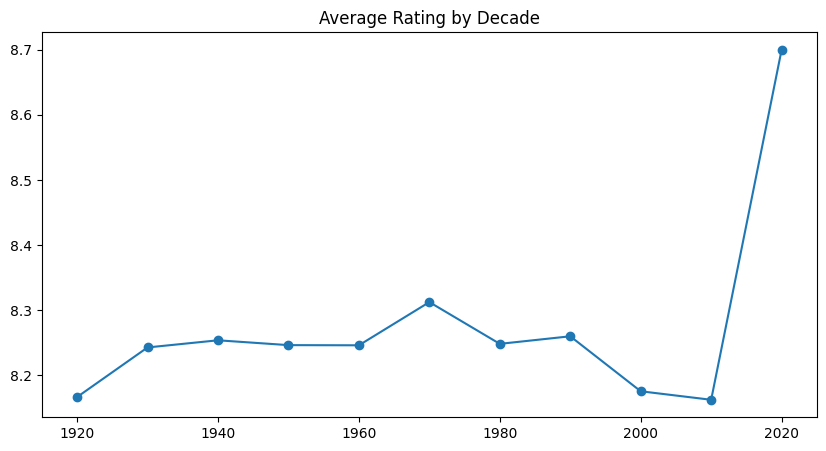

In [21]:
df['Decade'] = (df['Year'] // 10) * 10
decade_stats = df.groupby('Decade')['Rate'].agg(['mean', 'count'])

plt.figure(figsize=(10,5))
plt.plot(decade_stats.index, decade_stats['mean'], marker='o')
plt.title('Average Rating by Decade')
plt.show()
decade_stats

df.drop(columns="Decade", inplace=True)

Average movie ratings remain relatively stable across decades, generally ranging from 8.15 to 8.31. The higher average in the 2020s is based on only one movie, while the 1920s include only a few observations, so these averages are less reliable.

## 8. Genre Analysis

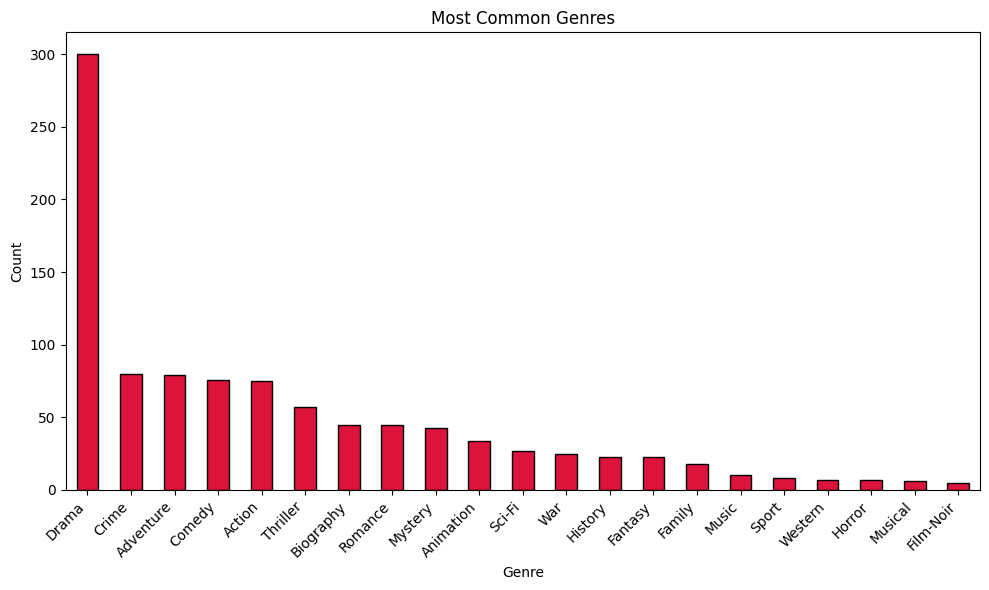

In [22]:
genre_counts = df.explode('Genre')['Genre'].value_counts()

plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Most Common Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8.1 Which Genre Has the Highest Average Rating?

In [23]:
genre_stats = df.explode('Genre').groupby('Genre')['Rate'].agg(['mean', 'count']).sort_values('mean', ascending=False)
genre_stats

,mean,count
Genre,,
Western,8.357143,7
Horror,8.271429,7
Family,8.266667,18
War,8.256000,25
Sci-Fi,8.255556,27
Crime,8.247500,80
Fantasy,8.234783,23
Action,8.230667,75
Adventure,8.226582,79


**Observation:Although `Western` has the highest average rating, it appears much less frequently than genres such as Drama or Action. Because of the small number of Western movies, this average should be interpreted carefully.

## 9. Relationship Between Rate and Metascore

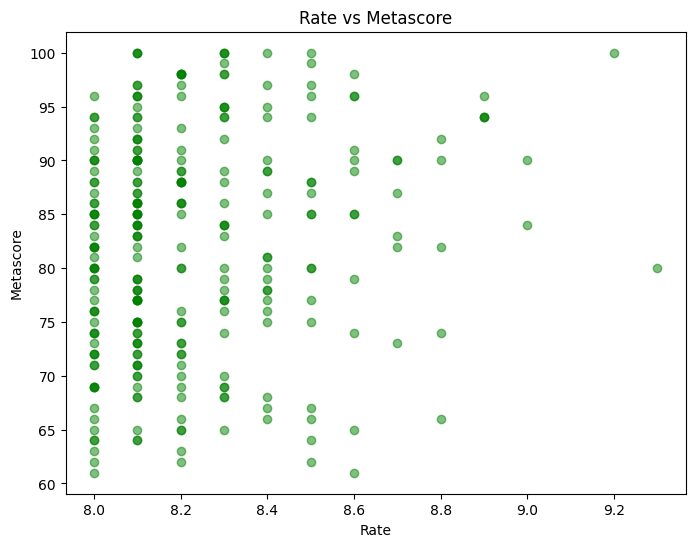

Correlation between Rate and Metascore: 0.17


In [24]:
plt.figure(figsize=(8,6))
plt.scatter(df['Rate'], df['Metascore'], alpha=0.5 ,color='green')
plt.title('Rate vs Metascore')
plt.xlabel('Rate')
plt.ylabel('Metascore')
plt.show()

correlation = df['Rate'].corr(df['Metascore'])
print(f"Correlation between Rate and Metascore: {correlation:.2f}")

**Observation:** IMDb `ratings` and `Metascores` do not always move together. Some movies receive high audience ratings but relatively lower critic scores, indicating differences between audience and critic evaluations.

## 10. Relationship Between Duration and Rate

Do longer movies get higher ratings?

In [25]:
correlation_duration = df['Duration'].corr(df['Rate'])
print(f"Correlation between Duration and Rate: {correlation_duration:.2f}")

Correlation between Duration and Rate: 0.18


**Observation:** A correlation coefficient of 0.18 between `Duration` and `Rate` indicates no meaningful linear relationship between a movie's length and its rating.

## 11. Correlation Heatmap

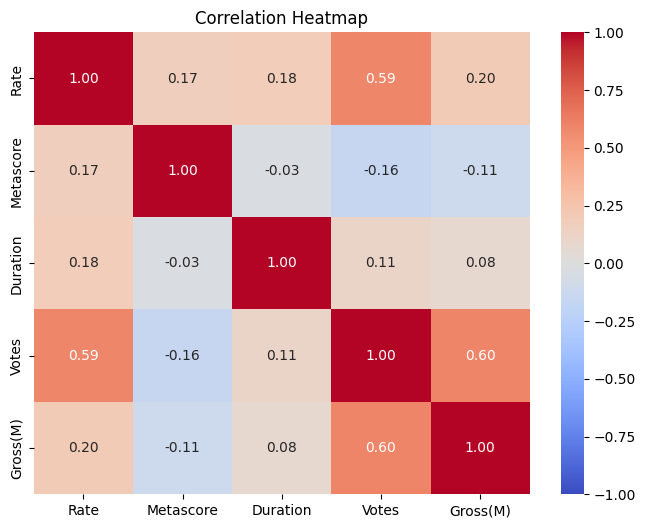

In [26]:
import seaborn as sns

numeric_cols = ['Rate', 'Metascore', 'Duration', 'Votes', 'Gross(M)']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

**Observation:** The weak correlation between `Gross` and `Rate` suggests that commercial success does not necessarily indicate higher audience ratings. In contrast, movies with more votes tend to generate higher gross revenue, indicating a stronger relationship between popularity and box office performance.

## 12. Directors and Stars Analysis

In [27]:
director_stats = df.groupby('Director')['Rate'].agg(['mean', 'count'])
director_stats = director_stats[director_stats['count'] >= 3].sort_values('mean', ascending=False)
director_stats.head(10)

,mean,count
Director,,
Francis Ford Coppola,8.866667,3
Peter Jackson,8.800000,3
Christopher Nolan,8.557143,7
David Fincher,8.500000,3
Sergio Leone,8.500000,4
Steven Spielberg,8.383333,6
Charles Chaplin,8.333333,6
Quentin Tarantino,8.333333,6
Martin Scorsese,8.328571,7


In [28]:
star_counts = df.explode('Stars')['Stars'].value_counts().head(10)
star_counts

Stars
Robert De Niro       9
Leonardo DiCaprio    8
Aamir Khan           8
Harrison Ford        7
Toshirô Mifune       7
Brad Pitt            6
Tom Hanks            6
Matt Damon           6
James Stewart        6
Charles Chaplin      6
Name: count, dtype: int64

Francis Ford Coppola and Peter Jackson have the highest average ratings among directors in this dataset, although each is represented by only three movies. Christopher Nolan has the largest number of movies among the highest-rated directors while maintaining a consistently high average rating. Among actors, Robert De Niro appears most frequently in highly rated movies.

## 13. Are the Top-Rated and Most-Voted Movies the Same?

In [29]:
top_rate = df.sort_values('Rate', ascending=False)[['Title', 'Rate']].head(10).reset_index(drop=True)
top_votes = df.sort_values('Votes', ascending=False)[['Title', 'Votes']].head(10).reset_index(drop=True)

top_comparison = pd.concat([top_rate, top_votes], axis=1)
top_comparison

,Title,Rate,Title,Votes
0,The Shawshank Redemption,9.3,The Shawshank Redemption,2295987
1,The Godfather,9.2,The Dark Knight,2260649
2,The Dark Knight,9.0,Inception,2022655
3,The Godfather: Part II,9.0,Fight Club,1820268
4,The Lord of the Rings: The Return of the King,8.9,Pulp Fiction,1792919
5,Pulp Fiction,8.9,Forrest Gump,1769309
6,Schindler's List,8.9,The Matrix,1643911
7,12 Angry Men,8.9,The Lord of the Rings: The Fellowship of the Ring,1630106
8,Inception,8.8,The Lord of the Rings: The Return of the King,1614369
9,Fight Club,8.8,The Godfather,1584782


**Observation:** Popularity (vote count) doesn't necessarily align with the highest rating.

## 14. Conclusion

- Most IMDb ratings fall between 8.0 and 8.2, reflecting the fact that the dataset contains only highly rated movies.
- - Outlier detection using the IQR method identified unusual values in variables such as `Duration`, `Votes`, and `Gross`. These observations were retained because they represent real characteristics of the movies rather than data errors.
- `Drama` is the most common genre, while `Western` has the highest average rating based on a much smaller number of movies.
- IMDb `ratings` and `Metascores` show only a weak relationship, suggesting that audience and critic opinions are not always consistent.
- `Vote` count is positively correlated with `Gross` revenue, whereas gross revenue alone has only a weak relationship with movie ratings.
- Christopher Nolan appears most frequently among the highest-rated directors while maintaining a consistently strong average rating.